In [4]:
USE_CUDA = True

# Dependencies

## Code

In [5]:
import warnings
from typing import Any, Callable

## Status

In [6]:
def print_status(message: str) -> None:
    print(f"\r{message:<80}", end="", flush=True)


def end_status(message: str = "") -> None:
    print(f"\r{message:<80}", flush=True)

In [7]:
def print_progress(current: int, total: int, prefix: str = "", width: int = 30) -> None:
    fraction = current / total if total else 0
    filled = int(width * fraction)
    bar = "█" * filled + "-" * (width - filled)
    print_status(f"{prefix} |{bar}| {current}/{total} ({fraction:.0%})")

## OS, Systems, and File's Manager

In [8]:
import os
import sys
import joblib

### Loading Data

In [9]:
def get_file_paths_in_folder(folder_path: str, file_extension: str) -> list[str]:
    file_paths = []
    for file_name in os.listdir(folder_path):
        if file_name.endswith(f".{file_extension}"):
            file_paths.append(os.path.join(folder_path, file_name))
    return sorted(file_paths)

### Dump and Load

In [10]:
def load(object_path: str) -> Any:
    return joblib.load(object_path)

In [11]:
def dump(obj: Any, dump_path: str) -> None:
    joblib.dump(obj, dump_path)

### File's Path

In [12]:
PATH_FOLDER_ORIGINAL_DATASET = "cse-cic-ids2018"
PATH_FOLDER_DATA_PIPELINE = "data-pipeline"
PATH_FOLDER_PARQUET_DATASET = os.path.join(PATH_FOLDER_DATA_PIPELINE, "01-raw-parquet")

## Data Processing

In [41]:
import re
import numpy as np
import pandas as pd
import polars as pl
import pyarrow.parquet as pq

In [14]:
if USE_CUDA:
    import cupy as cp
    import cudf

### Configurations

In [15]:
NUMERIC_DATA_TYPE = "float32"
LABEL_COLUMN = "label"

## Parallel Processing

In [16]:
def create_tasks_list(function: Callable, per_task_arguments: list, *shared_arguments: Any) -> list:
    tasks = []
    for per_task_argument in per_task_arguments:
        task = joblib.delayed(function)(per_task_argument, *shared_arguments)
        tasks.append(task)
    return tasks

In [17]:
def run_tasks_in_parallel(tasks: list, n_jobs: int = -1) -> list:
    with joblib.parallel_config(backend="loky", inner_max_num_threads=1):
        return joblib.Parallel(n_jobs=n_jobs)(tasks)

## Segragate Data

In [53]:
def convert_column(dataframe: pd.DataFrame, regex:str, original: str, updated:str) -> pd.DataFrame:
    df = dataframe.copy()
    df[updated] = df[original].str.extract(regex)[0]
    return df

In [54]:
def group_column(
    dataframe: pd.DataFrame,
    original: str,
    updated: str,
    regex: str,
    value_column: str,
) -> pd.DataFrame:
    df = convert_column(dataframe, regex, original, updated)
    return df.groupby(updated, as_index=False)[[value_column]].sum()

## Plotting

In [61]:
import matplotlib.pyplot as plt

### Plot Function

In [64]:
def plot_bar(
    dataframe: pd.DataFrame,
    x: str,
    y: str,
    title: str | None = None,
    xlabel: str | None = None,
    ylabel: str | None = None,
    figsize: tuple[int, int] = (10, 5),
    rotation: int = 45,
) -> None:
    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(dataframe[x].astype(str), dataframe[y], zorder=3)
    ax.set_title(title or f"{y} per {x}")
    ax.set_xlabel(xlabel or x)
    ax.set_ylabel(ylabel or y)
    ax.ticklabel_format(axis="y", style="plain")
    ax.grid(axis="y", linestyle="--", alpha=0.6, zorder=0)
    plt.xticks(rotation=rotation, ha="right")
    plt.tight_layout()
    plt.show()

# CSV To Parquet

## Configurations

In [18]:
CHUNK_SIZE = 100_000

COLUMNS_TO_DROP = {
    "flow id",
    "src ip",
    "source ip",
    "src port",
    "source port",
    "dst ip",
    "destination ip",
    "timestamp",
}

## Normalize Columns

In [19]:
def normalize_column_name(column_name: Any) -> str:
    column_name = str(column_name).strip().lower()
    column_name = re.sub(r"[^0-9a-z]+", "_", column_name)
    return column_name.strip("_")

In [20]:
def normalize_column_names(column_names: list) -> list[str]:
    normalized_column_names = []
    for column_name in column_names:
        normalized_column_names.append(normalize_column_name(column_name))
    return normalized_column_names

## Create Schema

In [21]:
def create_schema_columns(folder_path: str, columns_to_drop: set[str] = COLUMNS_TO_DROP) -> list[str]:
    columns = set()
    for file_path in get_file_paths_in_folder(folder_path, "csv"):
        raw_columns = pd.read_csv(file_path, nrows=0).columns.tolist()
        columns.update(normalize_column_names(raw_columns))
    columns -= set(normalize_column_names(list(columns_to_drop)))
    return sorted(columns)

In [22]:
def create_schema(folder_path: str) -> pd.DataFrame:
    columns = create_schema_columns(folder_path)

    dtypes = []
    for column in columns:
        if column == LABEL_COLUMN:
            dtypes.append("str")
        else:
            dtypes.append(NUMERIC_DATA_TYPE)

    return pd.DataFrame({"column": columns, "dtype": dtypes})

## Cast Numeric Column to `float32`

In [23]:
def cast_numeric_columns(
    dataframe: pd.DataFrame,
    numeric_data_type: Any = NUMERIC_DATA_TYPE,
) -> pd.DataFrame:
    dataframe = dataframe.copy()

    for column in dataframe.columns:
        if pd.api.types.is_numeric_dtype(dataframe[column]):
            dataframe[column] = dataframe[column].astype(numeric_data_type)

    return dataframe

## Apply Schema Template

In [24]:
def apply_schema_to_dataframe(
    dataframe: pd.DataFrame,
    schema: pd.DataFrame,
    numeric_data_type: str = NUMERIC_DATA_TYPE,
) -> pd.DataFrame:
    dataframe = dataframe.rename(columns=normalize_column_name)
    dataframe = dataframe.reindex(columns=schema["column"].tolist())

    for column, dtype in zip(schema["column"], schema["dtype"]):
        if not isinstance(dtype, str) or dtype == "":
            continue

        if dtype.startswith(("int", "float")):
            numeric_values = pd.to_numeric(dataframe[column], errors="coerce")
            dataframe[column] = numeric_values.astype(numeric_data_type)
        else:
            try:
                dataframe[column] = dataframe[column].astype(dtype)
            except (ValueError, TypeError) as error:
                warnings.warn(f"Could not cast column '{column}' to {dtype}: {error}")

    return dataframe

## Remove Duplicate Header

In [25]:
def remove_duplicate_header(dataframe: pd.DataFrame) -> pd.DataFrame:
    is_header_row = dataframe.eq(dataframe.columns.tolist(), axis=1).all(axis=1)
    return dataframe[~is_header_row].reset_index(drop=True)

## Clean A Single Chunk

In [26]:
def clean_chunk(dataframe: pd.DataFrame, schema: pd.DataFrame) -> pd.DataFrame:
    dataframe = remove_duplicate_header(dataframe)
    dataframe = apply_schema_to_dataframe(dataframe, schema)
    return dataframe

## Write Chunk to Parquet

In [27]:
def write_chunk_to_parquet(
    chunk: pd.DataFrame,
    chunk_index: int,
    csv_file_path: str,
    output_folder_path: str,
) -> str:
    os.makedirs(output_folder_path, exist_ok=True)
    base_name = os.path.splitext(os.path.basename(csv_file_path))[0]
    output_path = os.path.join(output_folder_path, f"{base_name}_part{chunk_index:04d}.parquet")
    chunk.to_parquet(output_path, index=False)
    return output_path

## Convert A Single CSV

In [ ]:
def convert_csv_to_parquet(
    csv_file_path: str,
    schema: pd.DataFrame,
    output_folder_path: str = PATH_FOLDER_PARQUET_DATASET,
    chunk_size: int = CHUNK_SIZE,
) -> list[str]:
    file_name = os.path.basename(csv_file_path)
    parquet_file_paths = []

    with pd.read_csv(csv_file_path, chunksize=chunk_size, low_memory=False) as chunks:
        for chunk_index, chunk in enumerate(chunks):
            chunk_index_interface = chunk_index + 1
            print_status(f"{file_name}: writing chunk {chunk_index_interface}")
            chunk = clean_chunk(chunk, schema)
            parquet_file_path = write_chunk_to_parquet(chunk, chunk_index_interface, csv_file_path, output_folder_path)
            parquet_file_paths.append(parquet_file_path)

    end_status(f"{file_name}: {len(parquet_file_paths)} chunks written")
    return parquet_file_paths

## Convert All CSV Files to Parquet

In [35]:
def convert_all_csv_to_parquet(
    csv_folder_path: str = PATH_FOLDER_ORIGINAL_DATASET,
    n_jobs: int = -1,
) -> None:
    csv_file_paths = get_file_paths_in_folder(csv_folder_path, "csv")
    schema = create_schema(csv_folder_path)

    tasks = create_tasks_list(convert_csv_to_parquet, csv_file_paths, schema)

    print_status(f"Converting {len(tasks)} CSV files to parquet")
    results = run_tasks_in_parallel(tasks, n_jobs)

    parquet_file_paths = []
    for result in results:
        parquet_file_paths.extend(result)

    end_status(f"Finished converting {len(csv_file_paths)} CSV files into {len(parquet_file_paths)} parquet files")

## Do the Converting

In [34]:
convert_all_csv_to_parquet()

2018-03-01-Thursday_TrafficForML_CICFlowMeter.csv: 4 chunks written             
2018-02-21-Wednesday_TrafficForML_CICFlowMeter.csv: 11 chunks written           
2018-02-23-Friday_TrafficForML_CICFlowMeter.csv: 11 chunks written              
2018-03-02-Friday_TrafficForML_CICFlowMeter.csv: 11 chunks written              
2018-02-14-Wednesday_TrafficForML_CICFlowMeter.csv: 11 chunks written           
2018-02-15-Thursday_TrafficForML_CICFlowMeter.csv: 11 chunks written            
2018-02-22-Thursday_TrafficForML_CICFlowMeter.csv: 11 chunks written            
2018-02-16-Friday_TrafficForML_CICFlowMeter.csv: 11 chunks written              
2018-02-28-Wednesday_TrafficForML_CICFlowMeter.csv: 7 chunks written            
2018-02-20-Tuesday_TrafficForML_CICFlowMeter.csv: 80 chunks written             
Finished converting 10 CSV files into 168 parquet files                         


['data-pipeline/01-raw-parquet/2018-02-14-Wednesday_TrafficForML_CICFlowMeter_part0000.parquet',
 'data-pipeline/01-raw-parquet/2018-02-14-Wednesday_TrafficForML_CICFlowMeter_part0001.parquet',
 'data-pipeline/01-raw-parquet/2018-02-14-Wednesday_TrafficForML_CICFlowMeter_part0002.parquet',
 'data-pipeline/01-raw-parquet/2018-02-14-Wednesday_TrafficForML_CICFlowMeter_part0003.parquet',
 'data-pipeline/01-raw-parquet/2018-02-14-Wednesday_TrafficForML_CICFlowMeter_part0004.parquet',
 'data-pipeline/01-raw-parquet/2018-02-14-Wednesday_TrafficForML_CICFlowMeter_part0005.parquet',
 'data-pipeline/01-raw-parquet/2018-02-14-Wednesday_TrafficForML_CICFlowMeter_part0006.parquet',
 'data-pipeline/01-raw-parquet/2018-02-14-Wednesday_TrafficForML_CICFlowMeter_part0007.parquet',
 'data-pipeline/01-raw-parquet/2018-02-14-Wednesday_TrafficForML_CICFlowMeter_part0008.parquet',
 'data-pipeline/01-raw-parquet/2018-02-14-Wednesday_TrafficForML_CICFlowMeter_part0009.parquet',
 'data-pipeline/01-raw-parquet

# Exploratory Data Analysis (EDA)

## Count Rows Per Days

In [68]:
FILE_COLUMN = "file"
DAY_COLUMN = "day"
ROW_COUNT_COLUMN = "rows"
DAY_REGEX = r"^(\d{4}-\d{2}-\d{2})"

In [58]:
def count_a_single_file_rows(file_path: str) -> int:
    return pq.ParquetFile(file_path).metadata.num_rows

In [66]:
def count_all_file_rows(folder_path: str = PATH_FOLDER_PARQUET_DATASET, file_column:str = FILE_COLUMN, row_count_column:str = ROW_COUNT_COLUMN) -> pd.DataFrame:
    file_paths = get_file_paths_in_folder(folder_path, "parquet")
    results = []
    for file_path in file_paths:
        results.append(
            {file_column: os.path.basename(file_path), row_count_column: count_a_single_file_rows(file_path)}
        )
    return pd.DataFrame(results)

In [70]:
results = group_column(count_all_file_rows(),FILE_COLUMN,DAY_COLUMN,DAY_REGEX,ROW_COUNT_COLUMN)
display(results)

,day,rows
0,2018-02-14,1048575
1,2018-02-15,1048575
2,2018-02-16,1048574
3,2018-02-20,7948748
4,2018-02-21,1048575
5,2018-02-22,1048575
6,2018-02-23,1048575
7,2018-02-28,613071
8,2018-03-01,331100
9,2018-03-02,1048575


### Plot Row Count Each Day

In [ ]:
def plot_bar(
    dataframe: pd.DataFrame,
    x: str,
    y: str,
    title: str | None = None,
    xlabel: str | None = None,
    ylabel: str | None = None,
    figsize: tuple[int, int] = (10, 5),
    rotation: int = 45,
) -> None:
    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(dataframe[x].astype(str), dataframe[y], zorder=3)
    ax.set_title(title or f"{y} per {x}")
    ax.set_xlabel(xlabel or x)
    ax.set_ylabel(ylabel or y)
    ax.ticklabel_format(axis="y", style="plain")
    ax.grid(axis="y", linestyle="--", alpha=0.6, zorder=0)
    plt.xticks(rotation=rotation, ha="right")
    plt.tight_layout()
    plt.show()

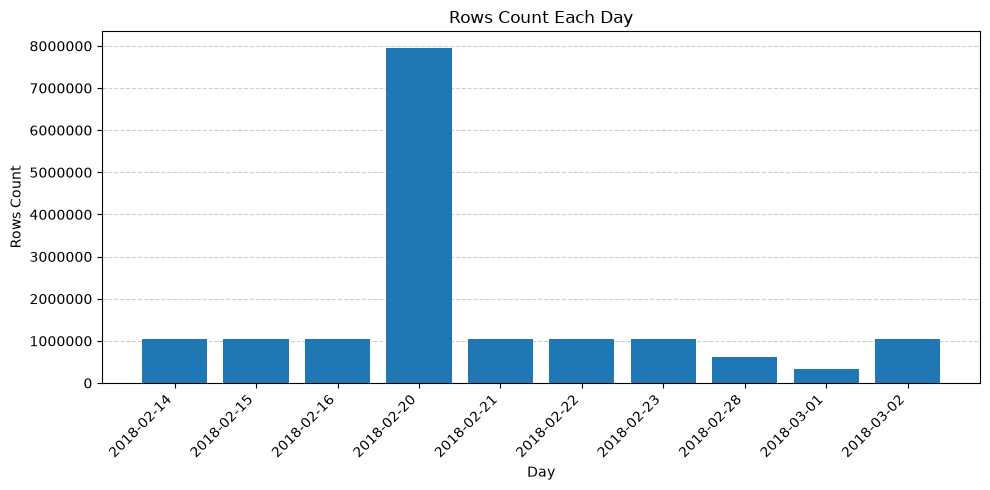

In [72]:
plot_bar(results,DAY_COLUMN,ROW_COUNT_COLUMN,"Rows Count Each Day","Day","Rows Count")
del results

## Count Label Classes

In [32]:
## count label each day

### Plot Label Classes (Each Day)

### Plot Label Classes (Total)

In [33]:
# missing, infinite values, min, max, mean, median, std, negative, zero, unique
# use polars

## Descriptive Statistics

## Infinite Values

## Missing Values

## NaN

## Constant Features

## Correlation Heatmaps